In [24]:
import matplotlib.pyplot as plt

from utils.data import DataManager
from utils.tools.config import (
    BENCHMARKS, 
    RISK_ANALYSIS,
    ANALYSIS_START_DATE,
    ANALYSIS_END_DATE
)

from utils.analysis.capm import (
    CAPMAnalyzer,
    PortfolioOptimizationAnalyzer,
    MultiAssetCAPMAnalyzer,
    CAPMReporter,
    PortfolioReporter,
    MultiAssetReporter
)

from utils.visualizations import (
    CAPMVisualizer,
    PortfolioOptimizationVisualizer,
    MultiAssetCAPMVisualizer
)

In [25]:
# 📊 CONFIGURACIÓN DEL ANÁLISIS
# Las fechas vienen de config.py (ANALYSIS_DATES)
# Personaliza aquí solo si necesitas valores diferentes

# Portfolio a analizar
TICKERS = ["SYF", "CF", "AFL", "NEM"]
BENCHMARK_NAME = "SP500"

# (Opcional) Fechas personalizadas - Deja vacío para usar config.py
USE_CUSTOM_DATES = False
START_DATE = ""  # Ej: "2020-01-01"
END_DATE = ""    # Ej: "2024-12-31"

# Constantes desde config
BENCHMARK_TICKER = BENCHMARKS[BENCHMARK_NAME]
RISK_FREE_RATE = RISK_ANALYSIS['risk_free_rate']
ANNUAL_FACTOR = RISK_ANALYSIS['annual_factor']

# Resolver fechas
if USE_CUSTOM_DATES and START_DATE and END_DATE:
    final_start, final_end = START_DATE, END_DATE
    print(f"📅 Usando fechas personalizadas: {final_start} → {final_end}")
else:
    final_start, final_end = ANALYSIS_START_DATE, ANALYSIS_END_DATE
    print(f"📅 Usando fechas de config.py: {final_start} → {final_end}")

print(f"\n📊 Portfolio: {len(TICKERS)} activos")
print(f"📈 Benchmark: {BENCHMARK_NAME} ({BENCHMARK_TICKER})")
print(f"💰 Risk-Free Rate: {RISK_FREE_RATE:.2%}")

📅 Usando fechas de config.py: 2020-01-01 → 2025-12-24

📊 Portfolio: 4 activos
📈 Benchmark: SP500 (^GSPC)
💰 Risk-Free Rate: 4.50%


In [26]:
# 🔧 INICIALIZACIÓN
# Crear DataManager compartido
data_manager = DataManager()

# Inicializar analyzers
capm_analyzer = CAPMAnalyzer(annual_factor=ANNUAL_FACTOR)
portfolio_optimizer = PortfolioOptimizationAnalyzer(annual_factor=ANNUAL_FACTOR)
multi_capm = MultiAssetCAPMAnalyzer(annual_factor=ANNUAL_FACTOR)

# Inicializar reporters
capm_reporter = CAPMReporter(capm_analyzer)
portfolio_reporter = PortfolioReporter(portfolio_optimizer)
multi_asset_reporter = MultiAssetReporter(multi_capm)

# Inicializar visualizers
capm_viz = CAPMVisualizer(capm_analyzer)
portfolio_viz = PortfolioOptimizationVisualizer(portfolio_optimizer)
multi_asset_viz = MultiAssetCAPMVisualizer(multi_capm)

print("✅ Analyzers, reporters y visualizers inicializados")

✅ Analyzers, reporters y visualizers inicializados


In [27]:
# 📥 DESCARGA DE DATOS
print("\n🔄 Descargando datos...")

assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK_NAME,
    start_date=final_start,
    end_date=final_end
)

# Calcular retornos
returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

print(f"\n✅ Datos descargados:")
print(f"   Período: {assets_prices.index[0].date()} → {assets_prices.index[-1].date()}")
print(f"   Días: {len(assets_prices)}")
print(f"   Activos: {list(returns.columns)}")

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


🔄 Descargando datos...
Descargando portafolio completo...
Período: 2020-01-01 → 2025-12-24
Período: 2020-01-01 → 2025-12-24
Portafolio descargado: 4 activos + benchmark

✅ Datos descargados:
   Período: 2020-01-02 → 2025-12-23
   Días: 1503
   Activos: ['SYF', 'CF', 'AFL', 'NEM']


In [29]:
# 📈 ANÁLISIS CAPM INDIVIDUAL
# Analiza un activo específico vs el mercado

ASSET_TO_ANALYZE = "META"  # Cambia aquí el ticker

# Si el activo no está en returns, descargarlo
if ASSET_TO_ANALYZE not in returns.columns:
    print(f"📥 Descargando datos para {ASSET_TO_ANALYZE}...")
    asset_prices = data_manager.download_assets(
        tickers=[ASSET_TO_ANALYZE],
        start_date=final_start,
        end_date=final_end
    )
    asset_returns = asset_prices[ASSET_TO_ANALYZE].pct_change().dropna()
    print(f"✅ Datos descargados para {ASSET_TO_ANALYZE}")
else:
    asset_returns = returns[ASSET_TO_ANALYZE]

print(f"\n🔍 Analizando {ASSET_TO_ANALYZE} con CAPM...\n")

capm_reporter.generate_report(
    asset_returns=asset_returns.values,
    market_returns=benchmark_returns.values,
    risk_free_rate=RISK_FREE_RATE,
    asset_name=ASSET_TO_ANALYZE
)

[*********************100%***********************]  1 of 1 completed

📥 Descargando datos para META...
Período: 2020-01-01 → 2025-12-24
✅ Datos descargados para META

🔍 Analizando META con CAPM...

                    ANÁLISIS CAPM: META                     
PARÁMETROS DEL MODELO
  Beta:                       1.325
  Correlación:                0.633
  R²:                         0.400
ALPHA (Jensen)
  Alpha Diario:              0.0437%
  Alpha Anual:                11.63%
SIGNIFICANCIA ESTADÍSTICA
  t-statistic:                0.787
  p-value:                   0.4313
  Significativo (α=0.05):  [NO]
[INFO] Alpha no significativo: el activo se comporta según lo esperado por CAPM


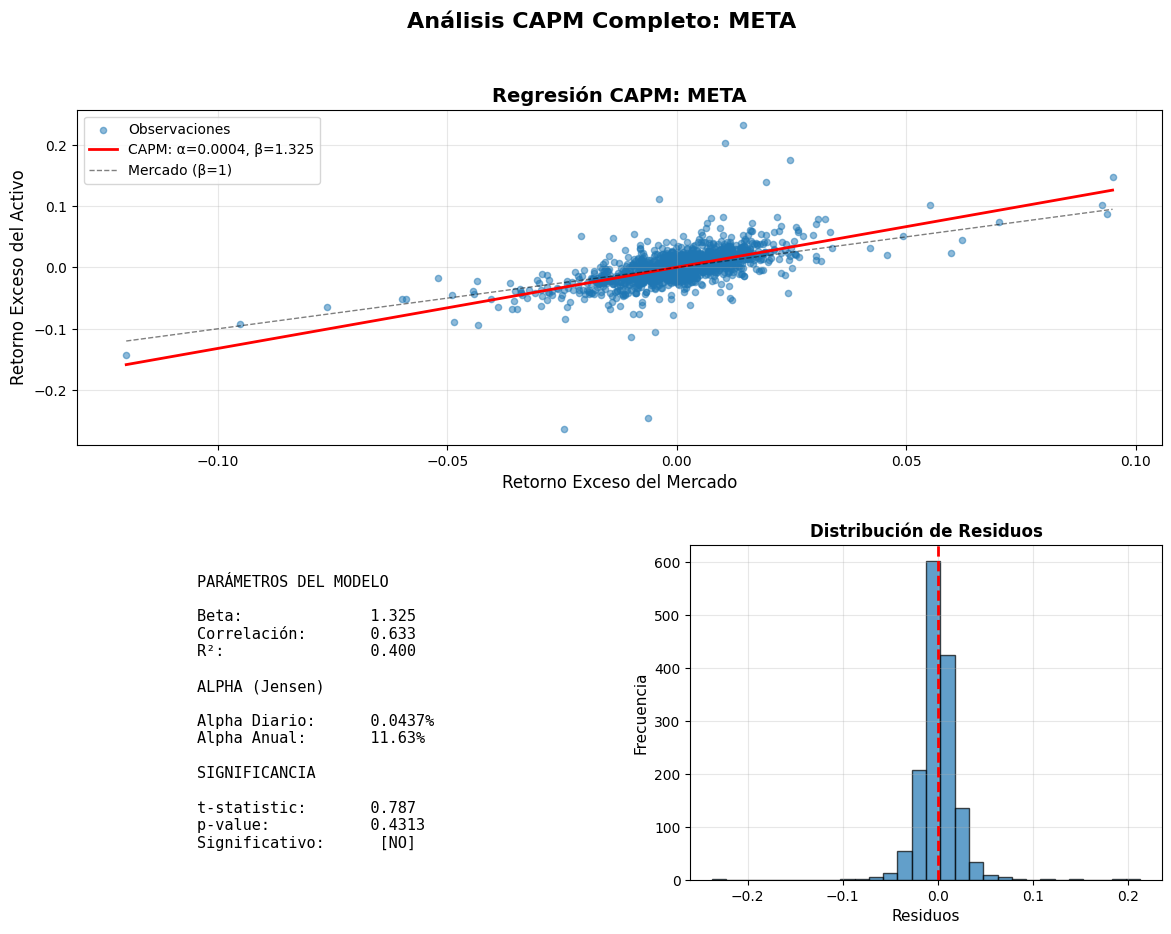

In [31]:
# 📊 VISUALIZACIÓN CAPM INDIVIDUAL
# Usar asset_returns si fue descargado, sino usar returns[ASSET_TO_ANALYZE]
if ASSET_TO_ANALYZE not in returns.columns:
    asset_returns_for_viz = asset_returns
else:
    asset_returns_for_viz = returns[ASSET_TO_ANALYZE]

fig1 = capm_viz.plot_capm_analysis(
    asset_returns=asset_returns_for_viz.values,
    market_returns=benchmark_returns.values,
    risk_free_rate=RISK_FREE_RATE,
    asset_name=ASSET_TO_ANALYZE
)
plt.show()


🔍 Calculando frontera eficiente...



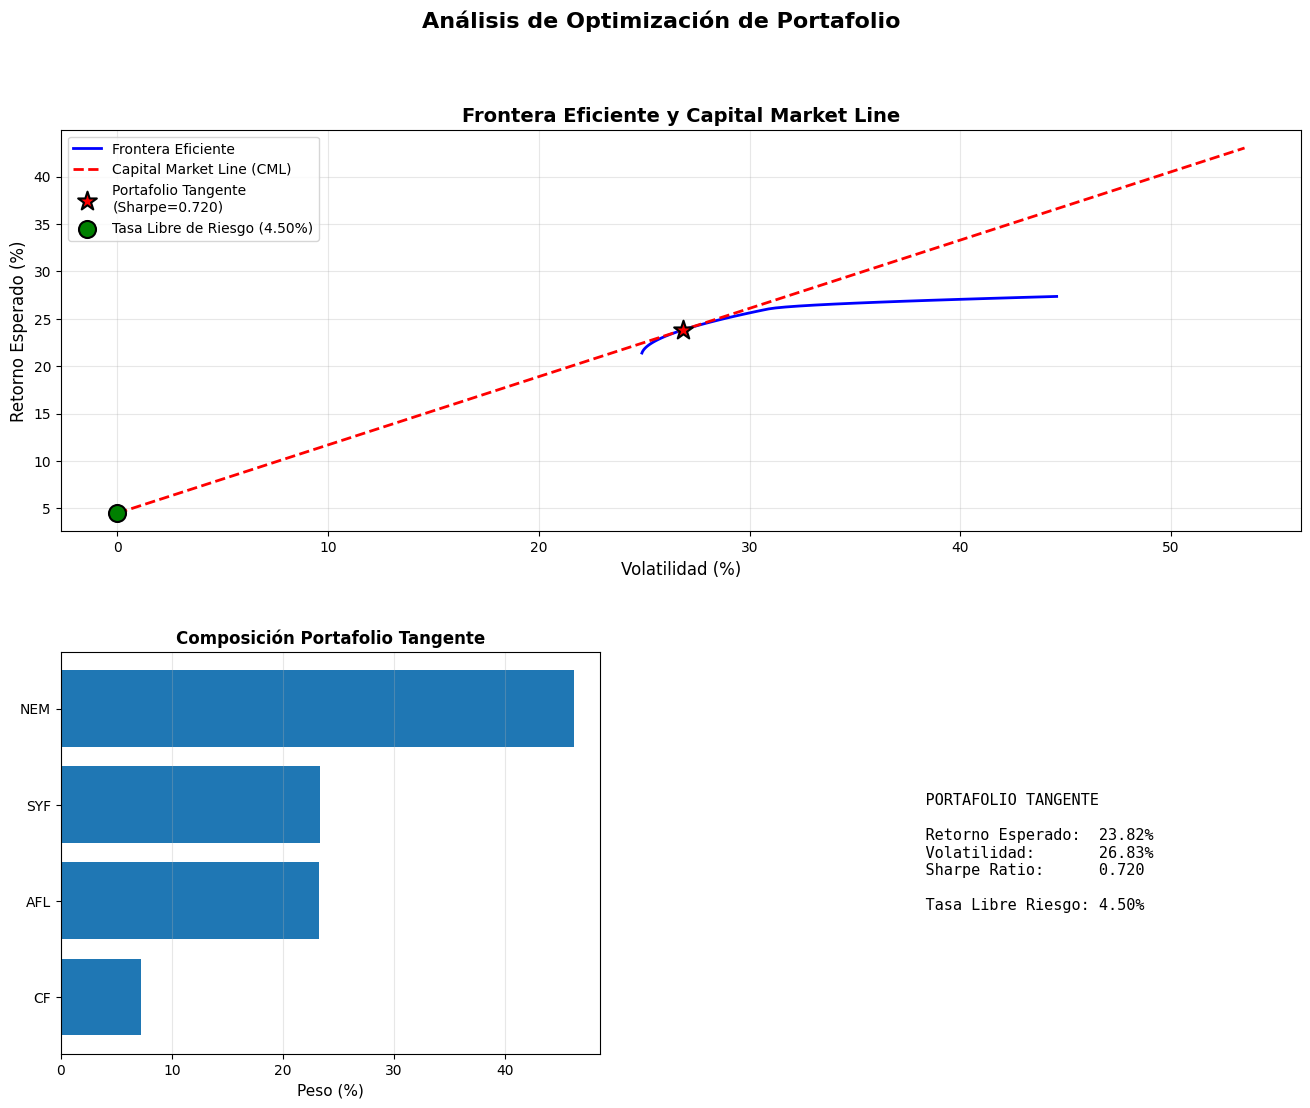

In [ ]:
# 🎯 FRONTERA EFICIENTE Y CML
print("\n🔍 Calculando frontera eficiente...\n")

fig2 = portfolio_viz.plot_efficient_frontier_analysis(
    returns=returns,
    risk_free_rate=RISK_FREE_RATE
)
plt.show()

In [ ]:
# ⭐ PORTFOLIO TANGENTE (Máximo Sharpe Ratio)
print("\n🔍 Calculando portfolio tangente...\n")

portfolio_reporter.generate_tangent_report(
    returns=returns,
    risk_free_rate=RISK_FREE_RATE
)


🔍 Calculando portfolio tangente...

            PORTAFOLIO TANGENTE (Máximo Sharpe)             
CARACTERÍSTICAS
  Retorno Esperado:           23.82%
  Volatilidad:                26.83%
  Sharpe Ratio:               0.720
COMPOSICIÓN DEL PORTAFOLIO
  NEM          46.25%
  SYF          23.32%
  AFL          23.23%
  CF            7.20%


In [ ]:
# 📊 ANÁLISIS CAPM MULTI-ACTIVO (Resumen)
print("\n🔍 Analizando todos los activos con CAPM...\n")

multi_asset_reporter.generate_summary_report(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)


🔍 Analizando todos los activos con CAPM...

                           ANÁLISIS CAPM MULTI-ACTIVO                           
Activos analizados: 4
ESTADÍSTICAS GENERALES
  Beta promedio:              0.927
  Alpha promedio (anual):      9.25%
  R² promedio:                0.277

[OK] Alphas significativos: 0 / 4
TOP 5 PERFORMERS (Alpha más alto)
       NEM        Alpha:   16.99%  Beta:  0.461
       SYF        Alpha:    7.63%  Beta:  1.503
       CF         Alpha:    6.55%  Beta:  0.854
       AFL        Alpha:    5.82%  Beta:  0.890
BOTTOM 5 PERFORMERS (Alpha más bajo)
       AFL        Alpha:    5.82%  Beta:  0.890
       CF         Alpha:    6.55%  Beta:  0.854
       SYF        Alpha:    7.63%  Beta:  1.503
       NEM        Alpha:   16.99%  Beta:  0.461
Nota: [OK] indica alpha estadísticamente significativo (p < 0.05)


In [ ]:
# 📋 TABLA DE RESULTADOS CAPM
capm_results = multi_capm.analyze_multiple(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)

print("\n📊 Resultados detallados de CAPM:\n")
display(capm_results)


📊 Resultados detallados de CAPM:



,alpha_daily,alpha_annual,beta,correlation,r_squared,t_statistic,p_value,is_significant
asset,,,,,,,,
NEM,0.000623,0.169923,0.461090,0.257891,0.066508,0.995883,0.319468,False
SYF,0.000292,0.076331,1.503304,0.691746,0.478512,0.620835,0.534803,False
CF,0.000252,0.065532,0.853533,0.436646,0.190660,0.429556,0.667580,False
AFL,0.000225,0.058216,0.890190,0.609114,0.371020,0.662365,0.507839,False


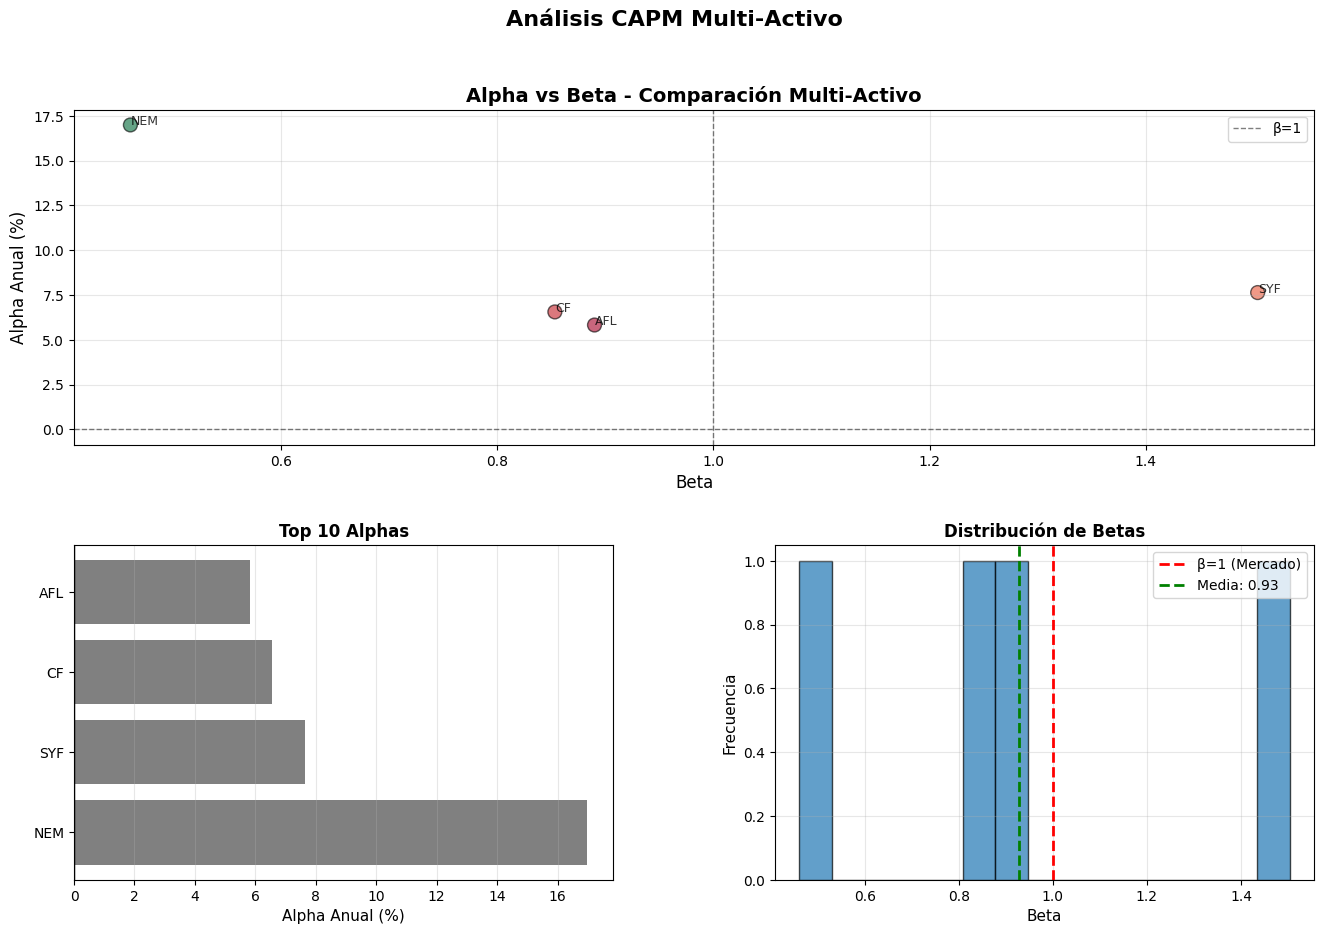

In [ ]:
# 📊 VISUALIZACIÓN MULTI-ACTIVO
fig3 = multi_asset_viz.plot_multi_asset_analysis(
    returns=returns,
    market_returns=benchmark_returns,
    risk_free_rate=RISK_FREE_RATE
)
plt.show()

In [ ]:
# 🔬 ANÁLISIS CAPM INDIVIDUAL
print("🔬 Análisis CAPM por activo:\n")
print(f"{'Ticker':<8} {'Alpha':<10} {'Beta':<8} {'R²':<8} {'Sig':<5}")
print("-" * 50)

for ticker in TICKERS:
    capm_result = capm_analyzer.analyze(
        asset_returns=returns[ticker].values,
        market_returns=benchmark_returns.values,
        risk_free_rate=RISK_FREE_RATE
    )
    
    is_sig = "✓" if capm_result['is_significant'] else "✗"
    
    print(f"{ticker:<8} {capm_result['alpha_annual']:>8.2%}  "
          f"{capm_result['beta']:>6.3f}  "
          f"{capm_result['r_squared']:>6.3f}  {is_sig:<5}")

🔬 Análisis CAPM por activo:

Ticker   Alpha      Beta     R²       Sig  
--------------------------------------------------
SYF         7.63%   1.503   0.479  ✗    
CF          6.55%   0.854   0.191  ✗    
AFL         5.82%   0.890   0.371  ✗    
NEM        16.99%   0.461   0.067  ✗    
